# 🌌 Linear regression!

## 🗂️ Project structure

1. Following the task description, you'll find a set of formal requirements that your solution must meet.
2. The primary measure of your success is the **test** accuracy of your machine learning model.
3. After completing each task, you must answer a series of questions, marked with ❓, to demonstrate your understanding of the techniques used.
4. You may create as many cells as needed, but the final results should be kept in a short and simple cell

## 🧪 A note on test data

In a departure from real-world scenarios, you will have access to the target variables of the test sets for each task. This has been arranged to facilitate the evaluation of your models. However, remember that in actual machine learning projects, test targets are not available, as predicting these is the ultimate goal of your supervised models.

## 📝 Submission guidelines

- For each problem, provide your code solution and model results inside **problem.ipynb** and **linear_models.py**.
- Answer the follow-up questions in markdown format within this notebook. A few sentences is enough, no requirements for length of answers.
- Ensure your explanations are clear, concise, and demonstrate a deep understanding of the techniques employed.
- Submit **problem.ipynb** and **linear_models.py** to Canvas. Deliever the notebook such that outputs are saved, ideally *restart* the kernel followed by *run all*.

Good luck!

---

## 🔋 Problem 1: Predicting power consumption

### ❗️ The problem

You must develop a predictive model to estimate **power consumption** based on **network activity**.
️
Use `LinearRegression` class from `linear_models.py` stored in this folder. Your task is to complete two functions: `fit` (find the optimal parameters of the regression) and `predict` (apply them to the test data).

### 📋 Formal requirements
1. **Implementation**: 
   - Use standard Python libraries (numpy, math, pandas, etc.)
   - Implement `LinearRegression` class from `linear_models.py` from scratch
   - Optimize weights and bias with gradient descent from scratch

2. **Discussion**:
   - Visualize the training loss curve. Is it stable?
   - Visualize the fitted curve and derive the resulting Energy consumption formula.
   - Analyze the prediction error distribution. What is an unbiased estimator?
   - What does it tell you when the gradient in SGD is close to zero?

In [133]:
# The `%autoreload` IPython magic command allows instant updates from `linear_models.py`.
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [125]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from linear_models import LinearRegression, LogisticRegression  # <--- You will implement this

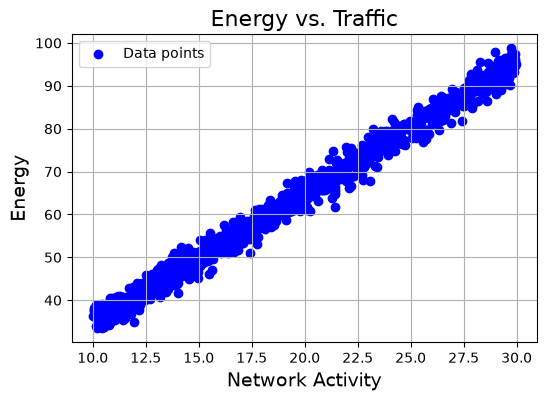

In [126]:
# Load data
data = pd.read_csv('regression.csv')

# Plot the data
plt.figure(figsize=(6, 4))
plt.scatter(data['Net_Activity'], data['Energy'], c='blue', label='Data points')
plt.grid(True)
plt.xlabel('Network Activity', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('Energy vs. Traffic', fontsize=16)
plt.legend()
plt.show()

In [127]:
# ====================================
# YOUR CODE GOES HERE
# ====================================
# Data
x = np.array(data['Net_Activity']).reshape(-1,1)
y = np.array(data['Energy'])


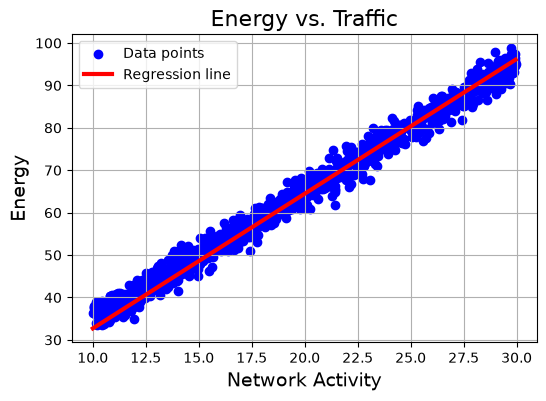

In [128]:
# Model
model = LinearRegression(lr = 0.0001, n_iterations= 10000)
# Tilpass modell
model.fit(x,y)

# Prediker
x_pred = np.array([[x.min()], [x.max()]])
y_pred = model.predict(x_pred)

# Tegn opp
plt.figure(figsize=(6, 4))
plt.scatter(data['Net_Activity'], data['Energy'], c='blue', label='Data points', zorder = 1)
plt.grid(True)
plt.xlabel('Network Activity', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('Energy vs. Traffic', fontsize=16)
# Regresjonslinje
plt.plot(x_pred.ravel(), y_pred, c = 'red', label = 'Regression line', zorder = 5, lw = 3)

plt.legend()
plt.show()

[3.17609556]
[0.94493352]


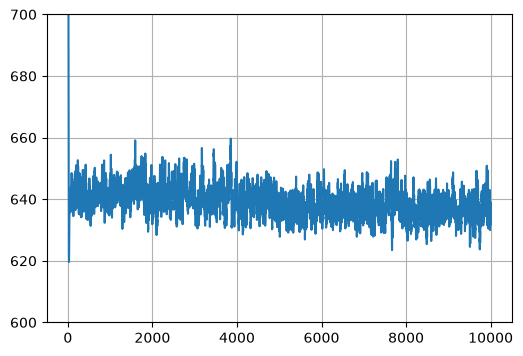

In [129]:
print(model.weights)
print(model.bias)

# Treningskurve tap
plt.figure(figsize=(6, 4))
plt.plot(range(len(model.loss_history)), model.loss_history)
plt.ylim((600,700))
plt.grid(True)
plt.show()

### ❓ Is the training loss curve stable?

To a certain degree, it is slowly coming down, but not very fast. Would say marginally stable
### ❓ Derive the resulting energy consumption formula

y = 3.21213343 + 1.03033756

### ❓ Analyze prediction error distribution. What is an unbiased estimator?
When the expected value is 0, meaning that the average value of a random parameter is 0.

### ❓ What does it tell you when the gradient in SGD is close to zero?
That you are close to a local minima, and because it is SGD, it is hopefully the global minima.

## 🔋 Problem 2: Logistic regression

### Your task
1. Implement logistic regression
2. Train your model on binary classification data
3. Engineer features to improve the model's performance

### Formal requirements
1. **Implementation**:
   - Same as before, use standard libraries
   - Implement gradient descent

2. **Performance**: Achieve at least **0.88** classification accuracy on the test set

3. **Discussion**:
   - Explain poor initial performance and your improvements
   - What is the model's inductive bias. Why is it important?
   - Plot the ROC curve, what does the area under the curve measure?

In [130]:
data = pd.read_csv('classification.csv')
train = data[data['split'] == 'train']
test = data[data['split'] == 'test']

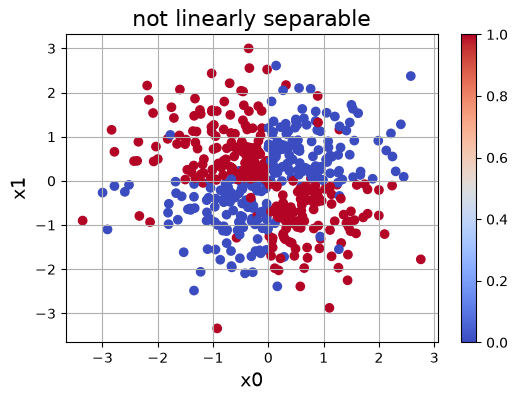

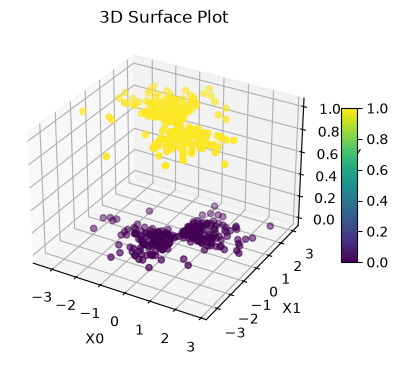

In [231]:
# visualize x0 and x1 of train on scatterplot with colors corresponding to y
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('not linearly separable', fontsize=16)
plt.colorbar()
plt.show()

fig = plt.figure(figsize= (6,4))
ax = plt.axes(projection = '3d')
p = ax.scatter3D(train['x0'], train['x1'], train['y'], c = train['y'])
ax.set_title("3D Surface Plot")
ax.set_xlabel("X0")
ax.set_ylabel("X1")
ax.set_zlabel("Y")
fig.colorbar(p, ax=ax, shrink=0.5, aspect=10)

plt.show()

In [206]:
# ====================================
# YOUR CODE GOES HERE
# ====================================
log = LogisticRegression(lr = 0.1)

X_train = train[['x0', 'x1']].values
y_train = train['y'].values
# print(np.shape(X_train))
# print(np.shape(y_train))

log.fit(X_train, y_train)

Precision: 0.5107296137339056
Recall: 0.49377593360995853
Accuracy: 0.528


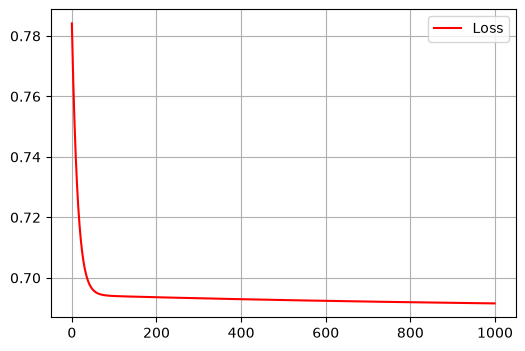

In [214]:
x_test = test[['x0', 'x1']].values
y_test = test['y'].values

pred = log.predict(x_test)

# Performance metrics
from sklearn.metrics import confusion_matrix
def accuracy_test(y_true, y_pred, model : LogisticRegression):
    conf = confusion_matrix(y_true, y_pred)
    precision = conf[1][1] / (conf[1][1] + conf[0][1])
    recall = conf[1][1] / (conf[1][1] + conf[1][0])
    accuracy = np.mean(y_true == y_pred)
    print("Precision: " + str(precision))
    print("Recall: " + str(recall))
    print("Accuracy: " + str(accuracy))

    epochs = np.arange(0, model.n_iterations, 1)
    plt.figure(figsize=(6,4))
    plt.plot(epochs, model.loss_history, c='red', label = "Loss")
    plt.grid(True)
    plt.legend()
    plt.show()


accuracy_test(y_test, pred, log)

Skalering:
Precision: 0.4541284403669725
Recall: 0.8215767634854771
Accuracy: 0.438


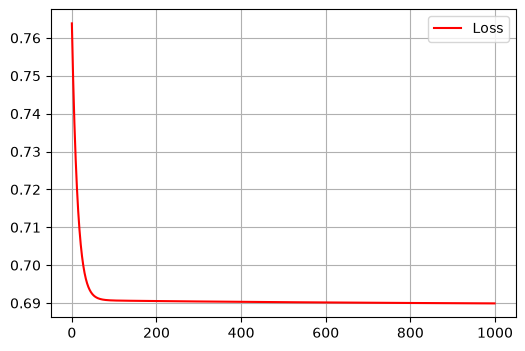

Feature engineering:
FE og skalering:
Precision: 0.9043478260869565
Recall: 0.8630705394190872
Accuracy: 0.89


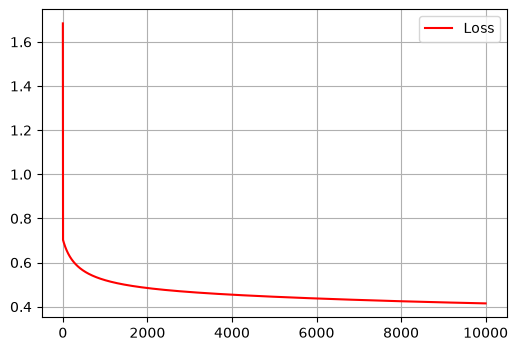

Precision: 0.91796875
Recall: 0.8969465648854962
Accuracy: 0.904


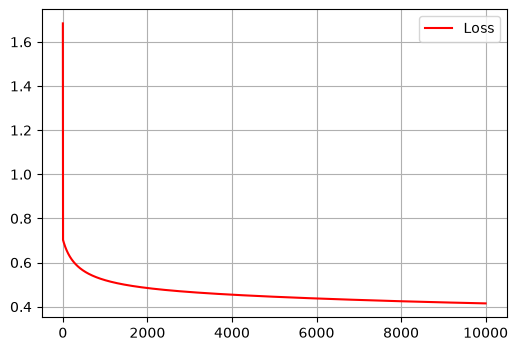

In [467]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()

X_train_scaled = min_max_scaler.fit_transform(X_train)
X_test_scaled = min_max_scaler.transform(x_test)

log = LogisticRegression(lr = 0.1)
log.fit(X_train_scaled, y_train)
pred = log.predict(X_test_scaled)

print("Skalering:")
accuracy_test(y_test, pred, log)


# Feature engineering
def add_features(X):
    x0 = X[:,0]
    x1 = X[:,1]
    return np.column_stack((
        x0,
        x1,
        x0 ** 2, x1 **2,
        x0 ** 3, x1 ** 3,
        x0 * x1,
        x0 * x1 ** 2,
        x0 * x1 ** 3,
        x1 * x0 ** 2,
        x1 * x0 ** 3,
    ))
X_train_fe = add_features(X_train)
x_test_fe = add_features(x_test)

log_model = LogisticRegression(lr = 0.1)
log_model.fit(X_train, y_train)

pred = log_model.predict(x_test)
print("Feature engineering:")
# accuracy_test(y_test, pred, log_model)

# FE og skalering
x_train_scale_fe = min_max_scaler.fit_transform(X_train_fe)
x_test_train_fe = min_max_scaler.transform(x_test_fe)

log1 = LogisticRegression(lr = 1.0, n_iterations=10000)
log1.fit(x_train_scale_fe, y_train)
pred = log1.predict(x_test_train_fe)

print("FE og skalering:")
accuracy_test(y_test, pred, log1)
accuracy_test(y_train, log1.predict(x_train_scale_fe), log1)

### ❓ Explain poor initial performance and your improvements

### ❓ What is the model's inductive bias? Why is it important?

### ❓ What does the area under the ROC curve measure?